In [1]:
import torch
import numpy as np
from matplotlib import pyplot as plt

import utilities as utils
import care

# Training a global operator on synthetic data

### Stationary synthetic dataset

In the synthetic case, the stationary time series include pure 10Hz signals, 24Hz signals, as well as their sum. This is displayed below.


inf >> dataset parameters:

 dataset  batches  timeseries length channels
--------  -------  ----------------- --------
   train     3500                200        1
   valid     1000                200        1
    test      500                200        1



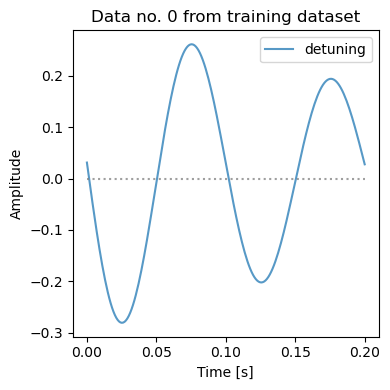

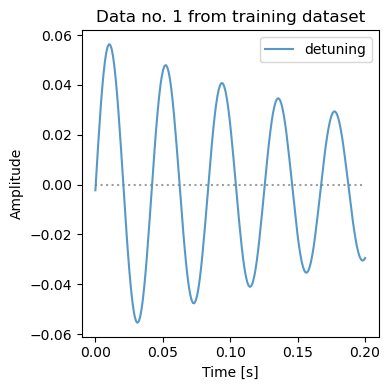

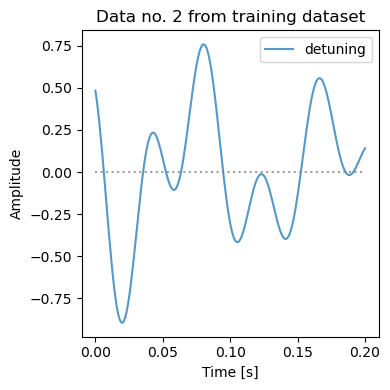

In [2]:
# --!------------------------------------------------------!
# --! display dataset metrics

dataset_dir     = 'cavity/train_sim_g'
timeseries_len  = 200
timestep        = 0.001
x_dims_n        = 1
x_len           = 200
utils.disp_dataset(dataset_dir, timeseries_len, timestep)

### Model instantiation

The model is instantiated with 4 basis functions: a sine and a cosine, as well as 2 data-driven functions. We set parameter $\tau=40$, as this value allows the DMD-like global operator to consistently identify two distinct complex eigenvalue pairs corresponding to the fast and slow oscillatory modes.

In [3]:
# --!--------------------------------------------------------------------------
# --! instantiate a model

# --! ensure reproducible results
seed = 5
torch.manual_seed(seed)

cfg = care.config(

    timeseries_dims_n     = x_dims_n,
    timeseries_sz         = x_len,
    timeseries_timestep   = timestep,

    funs={
        'sin'   : 2,
        'cos'   : 2,
        'data1' : 1,
        'data2' : 1,
    },
    fun_params_kern_sz    = 40,

    fit_weight_lin_global = 1.,
    fit_weight_lin_local  = 0.
)

model = care.detune(cfg)

### Global operator training

In [4]:
# --!--------------------------------------------------------------------------
# --! train the global operator

train_params = {
    'dataset_dir'   : dataset_dir,
    'timeseries_sz' : timeseries_len,
    'train_files_n' : 7,
    'batch_sz'      : 128,
    'epochs_n'      : 100,
    'x_sz'          : x_len,
    'is_verbose'    : True,
    'is_global'     : True,
    'learn_rate'    : 1e-3,
    'weight_decay'  : 1e-8,
    'alpha'         : 1.0
}

outs = utils.train(model, train_params)

loss_train_pred  = outs[0]
loss_train_lin_g = outs[1]
loss_train_lin_l = outs[2]
loss_valid_pred  = outs[3]
loss_valid_lin_g = outs[4]
loss_valid_lin_l = outs[5]

inf >> Number of data files for training : 7
inf >> processing training file number 1
inf >> processing training file number 2
inf >> processing training file number 3
inf >> processing training file number 4
inf >> processing training file number 5
inf >> processing training file number 6
inf >> processing training file number 7


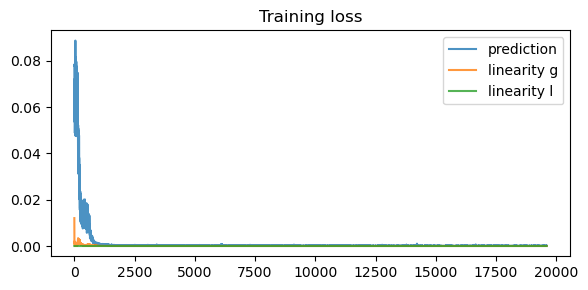

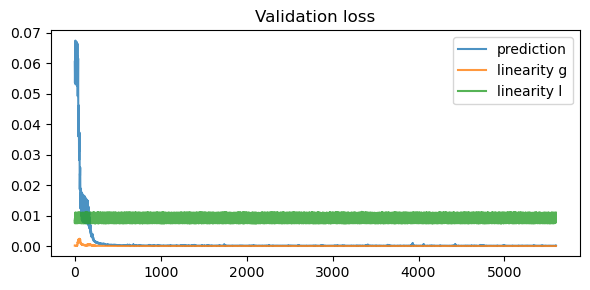

In [5]:
# --!--------------------------------------------------------------------------
# --! display training and validation statistics

with torch.no_grad():
    plt.figure(figsize=(6, 3))
    plt.title('Training loss')
    plt.plot(loss_train_pred, alpha=0.8, label='prediction')
    plt.plot(loss_train_lin_g, alpha=0.8, label='linearity g')
    plt.plot(loss_train_lin_l, alpha=0.8, label='linearity l')
    plt.legend()
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(6, 3))
    plt.title('Validation loss')
    plt.plot(loss_valid_pred, alpha=0.8, label='prediction')
    plt.plot(loss_valid_lin_g, alpha=0.8, label='linearity g')
    plt.plot(loss_valid_lin_l, alpha=0.8, label='linearity l')
    plt.legend()
    plt.tight_layout()
    plt.show()

In [6]:
# --!--------------------------------------------------------------------------
# --! save a trained global model

savemod_on = True
print(model.timeseries_dyn.weight)

if savemod_on:
    torch.save(model, 'data/models/care_sim_g.pt')

Parameter containing:
tensor([[ 0.7889, -0.0103,  0.0036,  0.1001],
        [ 0.8660, -0.3929, -0.6742, -0.0887],
        [-0.5034, -0.0661, -0.3378,  0.8845],
        [ 0.3287, -0.7923,  0.3279,  0.1410]], requires_grad=True)


# Training a local operator on synthetic data


inf >> dataset parameters:

 dataset  batches  timeseries length channels
--------  -------  ----------------- --------
   train     3500                200        1
   valid     1000                200        1
    test      500                200        1



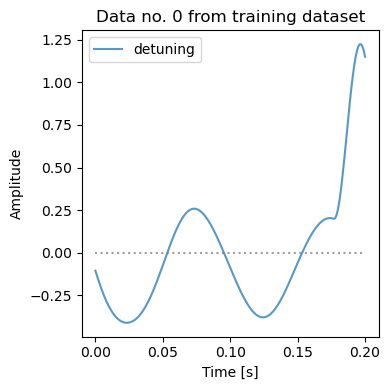

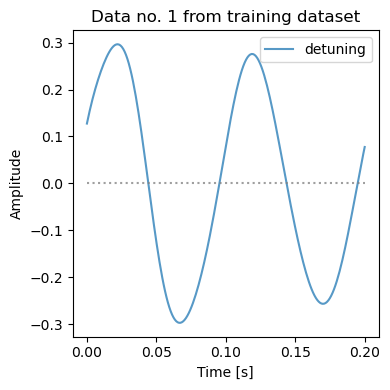

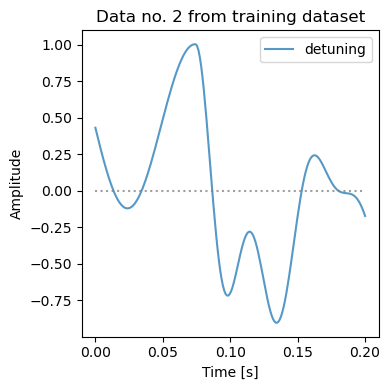

In [7]:
# --!------------------------------------------------------!
# --! display dataset metrics

dataset_dir = 'cavity/train_sim_l'
utils.disp_dataset(dataset_dir, timeseries_len, timestep)

### Local operator training

In [8]:
# --!--------------------------------------------------------------------------
# --! train the global operator

# --! we reuse the training parameters we defined above, but this time we
# --! update some of them, like the dataset directory, alpha, etc.
train_params['dataset_dir'] = dataset_dir
train_params['is_global']   = False
train_params['alpha']       = 0.5

outs = utils.train(model, train_params)

loss_train_pred  = outs[0]
loss_train_lin_g = outs[1]
loss_train_lin_l = outs[2]
loss_valid_pred  = outs[3]
loss_valid_lin_g = outs[4]
loss_valid_lin_l = outs[5]

inf >> Number of data files for training : 7
inf >> processing training file number 1
inf >> processing training file number 2
inf >> processing training file number 3
inf >> processing training file number 4
inf >> processing training file number 5
inf >> processing training file number 6
inf >> processing training file number 7


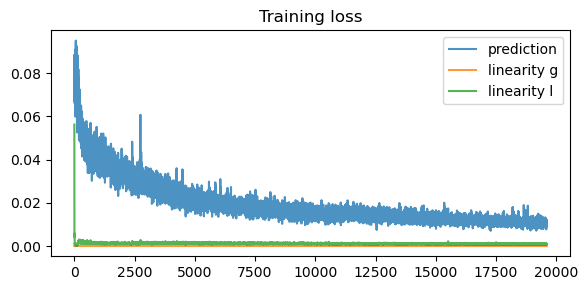

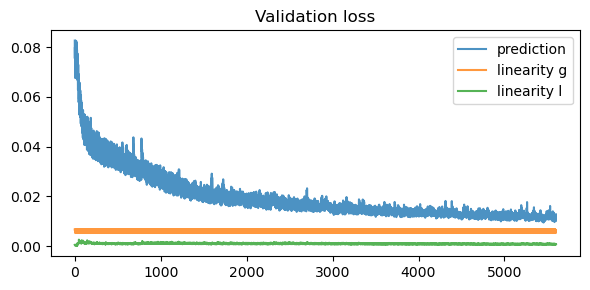

In [9]:
# --! display training statistics
with torch.no_grad():
    plt.figure(figsize=(6, 3))
    plt.title('Training loss')
    plt.plot(loss_train_pred, alpha=0.8, label='prediction')
    plt.plot(loss_train_lin_g, alpha=0.8, label='linearity g')
    plt.plot(loss_train_lin_l, alpha=0.8, label='linearity l')
    plt.legend()
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(6, 3))
    plt.title('Validation loss')
    plt.plot(loss_valid_pred, alpha=0.8, label='prediction')
    plt.plot(loss_valid_lin_g, alpha=0.8, label='linearity g')
    plt.plot(loss_valid_lin_l, alpha=0.8, label='linearity l')
    plt.legend()
    plt.tight_layout()
    plt.show()

In [11]:
# --!--------------------------------------------------------------------------
# --! save a trained local model

savemod_on = True

# --! sanity check that the global operator hasn't changed
print(model.timeseries_dyn.weight)

if savemod_on:
    torch.save(model, 'data/models/care_sim_l.pt')

Parameter containing:
tensor([[ 0.7889, -0.0103,  0.0036,  0.1001],
        [ 0.8660, -0.3929, -0.6742, -0.0887],
        [-0.5034, -0.0661, -0.3378,  0.8845],
        [ 0.3287, -0.7923,  0.3279,  0.1410]])


In [10]:
print(tata.shape)

# --! gather statistics -------------------------------------------------------

print(tata.shape)


stats_on = False

if stats_on:

    n = 30
    losses_train_pred = []
    losses_valid_pred = []
    losses_test_pred  = []

    for i in range(n):
        this = i + 1
        print(f'inf >> iteration number {this}')

        # --! preset the random seed
        torch.manual_seed(this)

        # --! recreate a model
        model = care.detune(cfg)

        # --! train the model
        outs = train(model, data_train, data_valid, bat_sz, verbose=False)
        loss_train_pred  = outs[0]
        loss_valid_pred  = outs[3]
        with torch.no_grad():
            losses_train_pred.append(loss_train_pred[-1])
            losses_valid_pred.append(loss_valid_pred[-1])

        # --! test the model
        with torch.no_grad():
            loss_test_pred = test(model, data_test, bat_sz)
            losses_test_pred.append(np.mean(loss_test_pred))


NameError: name 'tata' is not defined

In [ ]:
# --! display statistics ------------------------------------------------------

if stats_on:
    with torch.no_grad():
        pred_train_mean = np.mean(losses_train_pred)
        pred_valid_mean = np.mean(losses_valid_pred)
        pred_test_mean  = np.mean(losses_test_pred)

        pred_train_std  = np.std(losses_train_pred)
        pred_valid_std  = np.std(losses_valid_pred)
        pred_test_std   = np.std(losses_test_pred)

        print(f'inf >> number of iterations is {n}')

        print(f'inf >> prediction train mean is {pred_train_mean}')
        print(f'inf >> prediction train std is {pred_train_std}')

        print(f'inf >> prediction valid mean is {pred_valid_mean}')
        print(f'inf >> prediction valid std is {pred_valid_std}')

        print(f'inf >> prediction test mean is {pred_test_mean}')
        print(f'inf >> prediction test std is {pred_test_std}')


In [ ]:
if stats_on:
    with torch.no_grad():
        plt.figure()
        plt.plot(losses_train_pred, label='train')
        plt.plot(losses_valid_pred, label='valid')
        plt.plot(losses_test_pred, label='test')
        plt.legend()
        plt.show()